In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
#balíčky

In [3]:
def ntaylor(b,x1,x2,r,v,c):

    b1, b2 = b #souradnice clusteru
    f= np.cos((x1*np.pi)/5)*np.sin((x2*np.pi)/3) #puvodni funkce
    
    d_x1= np.cos((x1*np.pi+v)/5)*np.sin((x2*np.pi)/3)
    d_x2= np.cos((x1*np.pi)/5)*np.sin((x2*np.pi+v)/3)
    
    p_x1 = np.cos((x1*np.pi-v)/5)*np.sin((x2*np.pi)/3)
    p_x2 = np.cos((x1*np.pi)/5)*np.sin((x2*np.pi-v)/3)
    
    fx1 = (d_x1 - p_x1)/2*v
    fx2 = (d_x2 - p_x2)/2*v   #centralni diference

    fx1x1 = (d_x1 - 2*f + p_x1)/v**2
    fx2x2 = (d_x2 - 2*f + p_x2)/v**2

    dx1 = x1 - b1
    dx2 = x2 - b2         #vzdalenost stredu
    
    if r == 1:
        taylor= f + fx1*(x1 - b1) + fx2*(x2 - b2)
    else:
        taylor= f +  fx1*(x1 - b1) + fx2*(x2 - b2) +(fx1x1/2*(x1-b1)**2) +(fx2x2/2*(x2-b2)**2)
    return taylor
#funkce b=stred clustery, v=krok derivace

In [4]:
x1 = np.linspace(-3, 4*np.pi, 100)
x2 = np.linspace(-3, 4*np.pi, 100)
x1,x2 = np.meshgrid(x1,x2)

y=np.cos((x1*np.pi)/5)*np.sin((x2*np.pi)/3)

In [5]:
points = np.column_stack((x1.ravel(), x2.ravel()))

k = 4
kmeans = KMeans(n_clusters=k, random_state=0).fit(points)

centers = kmeans.cluster_centers_
b = [tuple(float(round(x, 2)) for x in c) for c in centers]

print('Centra clusteru:', b)

Centra clusteru: [(8.76, 0.9), (0.81, 8.67), (0.9, 0.8), (8.67, 8.76)]


In [10]:
r = int(input('Zadej řád derivace: '))
v = float(input('Zadej krok num. derivace: '))
#vstupy

Zadej řád derivace:  2
Zadej krok num. derivace:  1


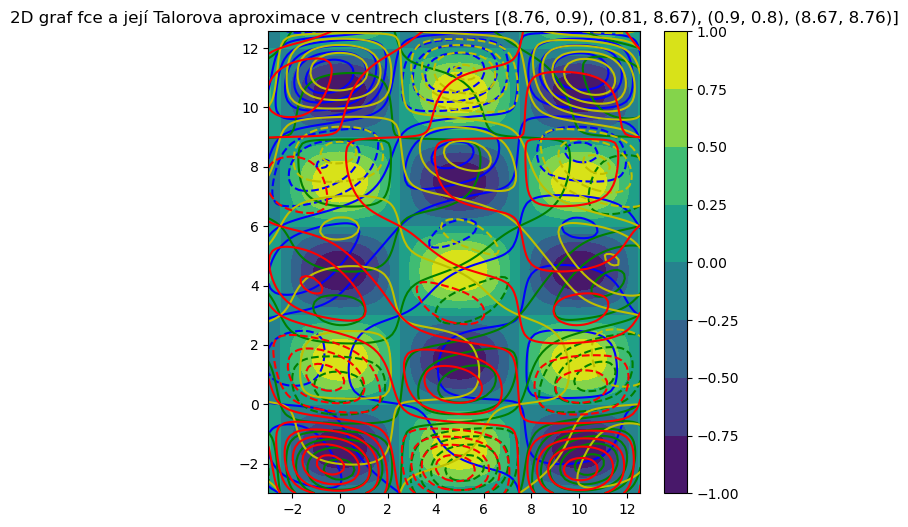

In [11]:

plt.figure(figsize=(6,6))
plt.contourf(x1,x2,y)
plt.colorbar()

colours = ['b','g','y','r']

for i in range(len(b)) :
    yn = ntaylor(b[i],x1, x2,r,v,c=colours[i])
    
    cs = plt.contour(x1, x2, yn, levels=10, colors=colours[i])
   
plt.title('2D graf fce a její Talorova aproximace v centrech clusters {}' .format(b))
plt.show()

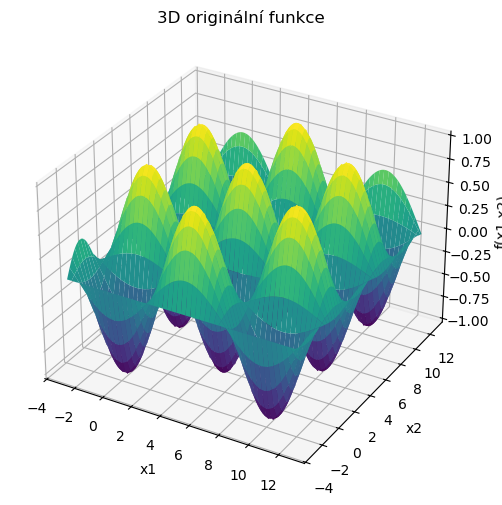

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, y, cmap='viridis')
ax.set_title("3D originální funkce")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")

plt.show()

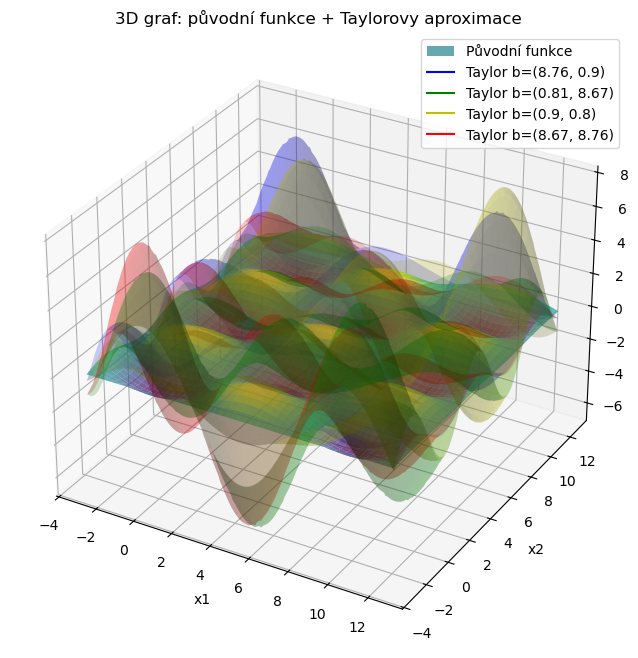

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, y, cmap='viridis', alpha=0.7, label='Původní funkce')

for i in range(len(b)):
    yn = ntaylor(b[i], x1, x2, r, v, c=colours[i])
    ax.plot_surface(x1, x2, yn, color=colours[i], alpha=0.2)
    ax.plot([], [], color=colours[i], label=f"Taylor b={b[i]}")

ax.set_title("3D graf: původní funkce + Taylorovy aproximace")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")

plt.legend()
plt.show()